# NYC Yellow Taxi Fare Analysis Using Hypothesis Testing

## Project Overview

This project investigates whether passengers who pay by **credit card** spend significantly more on taxi fares than those who pay by **cash**.

Using the NYC Yellow Taxi Trip dataset, the analysis follows a complete data analytics workflow including:

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Outlier Detection
- Normality Assessment
- Hypothesis Testing
- Business Insights

The objective is to determine whether payment method has a statistically significant relationship with fare amount.

## Business Problem

Taxi companies are interested in understanding customer spending behavior.

One important business question is:

> Do passengers who pay by credit card spend more than passengers who pay by cash?

If a significant difference exists, companies can promote digital payments through incentives, loyalty programs, and targeted marketing campaigns.

## Import Required Libraries

The following Python libraries are used throughout this analysis:

- Pandas
- NumPy
- Matplotlib
- SciPy
- Statsmodels

In [115]:
# Import required libraries for data manipulation, visualization, and statistical analysis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

## Dataset Information

**Dataset:** NYC Yellow Taxi Trip Records (2015)

The dataset contains millions of taxi trips recorded in New York City, including information about:

- Pickup and drop-off timestamps
- Trip distance
- Passenger count
- Payment method
- Fare amount
- Total amount
- Vendor information

This analysis focuses on the variables required to compare fare amounts between different payment methods.

In [7]:
# Load the NYC Yellow Taxi dataset
df=pd.read_csv(r"C:\Users\Ashraful\Downloads\2015_Yellow_Taxi_Trip_Data.csv")
df

,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,fare_amount,extra,mta_tax,tip_amount,tolls_amount,total_amount,vendor_id,pickup_datetime,dropoff_datetime,rate_code,payment_type,imp_surcharge
0,1,2.40,-73.978844,40.736423,NaN,N,-73.995918,40.759132,10.5,0.5,0.5,1.00,0.00,12.80,1.0,04/11/2015 12:47:57 AM,04/11/2015 12:58:14 AM,1.0,1.0,NaN
1,1,13.40,-73.863617,40.769844,NaN,N,-74.008499,40.706463,41.5,0.0,0.5,9.57,5.54,57.41,2.0,06/02/2015 02:03:47 PM,06/02/2015 02:43:53 PM,1.0,1.0,NaN
2,1,2.40,-73.994179,40.751072,NaN,N,-73.981926,40.729332,13.0,0.0,0.5,3.45,0.00,17.25,1.0,06/16/2015 10:25:46 AM,06/16/2015 10:43:38 AM,1.0,1.0,NaN
3,1,2.10,-73.972511,40.792622,NaN,N,-73.962967,40.772507,9.5,1.0,0.5,1.00,0.00,12.30,1.0,02/09/2015 07:04:37 PM,02/09/2015 07:14:23 PM,1.0,1.0,NaN
4,1,0.91,-73.973129,40.744179,NaN,N,-73.966911,40.754997,5.0,0.5,0.5,1.26,0.00,7.56,2.0,03/13/2015 09:24:17 PM,03/13/2015 09:27:19 PM,1.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8359230,1,0.90,-73.992706,40.748280,NaN,N,-73.992363,40.73850{,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8359231,"""error"" : true",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8359232,"""message"" : ""Internal error""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8359233,"""status"" : 500",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Initial Data Exploration
df.head()

,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,fare_amount,extra,mta_tax,tip_amount,tolls_amount,total_amount,vendor_id,pickup_datetime,dropoff_datetime,rate_code,payment_type,imp_surcharge
0,1,2.40,-73.978844,40.736423,NaN,N,-73.995918,40.759132,10.5,0.5,0.5,1.00,0.00,12.80,1.0,04/11/2015 12:47:57 AM,04/11/2015 12:58:14 AM,1.0,1.0,NaN
1,1,13.40,-73.863617,40.769844,NaN,N,-74.008499,40.706463,41.5,0.0,0.5,9.57,5.54,57.41,2.0,06/02/2015 02:03:47 PM,06/02/2015 02:43:53 PM,1.0,1.0,NaN
2,1,2.40,-73.994179,40.751072,NaN,N,-73.981926,40.729332,13.0,0.0,0.5,3.45,0.00,17.25,1.0,06/16/2015 10:25:46 AM,06/16/2015 10:43:38 AM,1.0,1.0,NaN
3,1,2.10,-73.972511,40.792622,NaN,N,-73.962967,40.772507,9.5,1.0,0.5,1.00,0.00,12.30,1.0,02/09/2015 07:04:37 PM,02/09/2015 07:14:23 PM,1.0,1.0,NaN
4,1,0.91,-73.973129,40.744179,NaN,N,-73.966911,40.754997,5.0,0.5,0.5,1.26,0.00,7.56,2.0,03/13/2015 09:24:17 PM,03/13/2015 09:27:19 PM,1.0,1.0,NaN


In [12]:
# Select features relevant to the business problem
df1=df[['passenger_count','trip_distance','fare_amount','total_amount','pickup_datetime','dropoff_datetime','payment_type']]
df1

,passenger_count,trip_distance,fare_amount,total_amount,pickup_datetime,dropoff_datetime,payment_type
0,1,2.40,10.5,12.80,04/11/2015 12:47:57 AM,04/11/2015 12:58:14 AM,1.0
1,1,13.40,41.5,57.41,06/02/2015 02:03:47 PM,06/02/2015 02:43:53 PM,1.0
2,1,2.40,13.0,17.25,06/16/2015 10:25:46 AM,06/16/2015 10:43:38 AM,1.0
3,1,2.10,9.5,12.30,02/09/2015 07:04:37 PM,02/09/2015 07:14:23 PM,1.0
4,1,0.91,5.0,7.56,03/13/2015 09:24:17 PM,03/13/2015 09:27:19 PM,1.0
...,...,...,...,...,...,...,...
8359230,1,0.90,NaN,NaN,NaN,NaN,NaN
8359231,"""error"" : true",NaN,NaN,NaN,NaN,NaN,NaN
8359232,"""message"" : ""Internal error""",NaN,NaN,NaN,NaN,NaN,NaN
8359233,"""status"" : 500",NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# Inspect data types before preprocessing
df1.dtypes

passenger_count             object
trip_distance              float64
fare_amount                float64
total_amount               float64
pickup_datetime     datetime64[us]
dropoff_datetime    datetime64[us]
payment_type               float64
dtype: object

## Data Cleaning

Before conducting any statistical analysis, the dataset was cleaned to improve data quality.

The following preprocessing steps were performed:

- Removed missing values
- Removed duplicate records
- Converted data types
- Created trip duration feature
- Filtered invalid observations
- Verified data consistency

These steps ensure that subsequent analyses are based on reliable and accurate data.

In [21]:
# 1. Datetime columns are already correct (datetime64[us]), but keeping this here is safe
df1['pickup_datetime'] = pd.to_datetime(df1['pickup_datetime'])
df1['dropoff_datetime'] = pd.to_datetime(df1['dropoff_datetime'])

# 2. Fix passenger_count: Force the 'error' text to NaN, fill missing with 0, then convert
df1['passenger_count'] = pd.to_numeric(df1['passenger_count'], errors='coerce').fillna(0).astype('int64')

# 3. Fix payment_type: Fill any hidden missing values (NaN) with 0, then convert to int64
df1['payment_type'] = df1['payment_type'].fillna(0).astype('int64')

In [22]:
# Verify data types after preprocessing
df1.dtypes

passenger_count              int64
trip_distance              float64
fare_amount                float64
total_amount               float64
pickup_datetime     datetime64[us]
dropoff_datetime    datetime64[us]
payment_type                 int64
dtype: object

In [24]:
# Create a new feature: Trip Duration (minutes)
df1['duration']=df1['dropoff_datetime']-df1['pickup_datetime']
df1['duration']=df1['duration'].dt.total_seconds()/60
df1

,passenger_count,trip_distance,fare_amount,total_amount,pickup_datetime,dropoff_datetime,payment_type,duration
0,1,2.40,10.5,12.80,2015-04-11 00:47:57,2015-04-11 00:58:14,1,10.283333
1,1,13.40,41.5,57.41,2015-06-02 14:03:47,2015-06-02 14:43:53,1,40.100000
2,1,2.40,13.0,17.25,2015-06-16 10:25:46,2015-06-16 10:43:38,1,17.866667
3,1,2.10,9.5,12.30,2015-02-09 19:04:37,2015-02-09 19:14:23,1,9.766667
4,1,0.91,5.0,7.56,2015-03-13 21:24:17,2015-03-13 21:27:19,1,3.033333
...,...,...,...,...,...,...,...,...
8359230,1,0.90,NaN,NaN,NaT,NaT,0,NaN
8359231,0,NaN,NaN,NaN,NaT,NaT,0,NaN
8359232,0,NaN,NaN,NaN,NaT,NaT,0,NaN
8359233,0,NaN,NaN,NaN,NaT,NaT,0,NaN


In [28]:
# Identify missing values
df1.isnull().sum()

passenger_count     0
trip_distance       0
fare_amount         0
total_amount        0
pickup_datetime     0
dropoff_datetime    0
payment_type        0
duration            0
dtype: int64

In [27]:
# Remove missing observations from selected variables
df1.dropna(inplace=True)
df1

,passenger_count,trip_distance,fare_amount,total_amount,pickup_datetime,dropoff_datetime,payment_type,duration
0,1,2.40,10.5,12.80,2015-04-11 00:47:57,2015-04-11 00:58:14,1,10.283333
1,1,13.40,41.5,57.41,2015-06-02 14:03:47,2015-06-02 14:43:53,1,40.100000
2,1,2.40,13.0,17.25,2015-06-16 10:25:46,2015-06-16 10:43:38,1,17.866667
3,1,2.10,9.5,12.30,2015-02-09 19:04:37,2015-02-09 19:14:23,1,9.766667
4,1,0.91,5.0,7.56,2015-03-13 21:24:17,2015-03-13 21:27:19,1,3.033333
...,...,...,...,...,...,...,...,...
8359225,2,1.57,8.0,9.30,2015-01-11 01:01:54,2015-01-11 01:09:56,2,8.033333
8359226,1,2.20,11.5,15.35,2015-06-11 20:06:32,2015-06-11 20:22:24,1,15.866667
8359227,1,2.19,9.5,13.00,2015-04-03 18:58:06,2015-04-03 19:08:04,1,9.966667
8359228,3,1.08,6.0,8.58,2015-02-19 19:27:35,2015-02-19 19:33:32,1,5.950000


In [29]:
# Detect duplicate records
df1[df1.duplicated()]

,passenger_count,trip_distance,fare_amount,total_amount,pickup_datetime,dropoff_datetime,payment_type,duration
2555613,1,0.0,2.2,3.0,2015-01-09 17:40:36,2015-01-09 17:43:28,2,2.866667
2642697,1,0.0,2.2,3.0,2015-01-09 17:40:36,2015-01-09 17:43:28,2,2.866667
2642698,1,0.0,2.2,3.0,2015-01-09 17:40:36,2015-01-09 17:43:28,2,2.866667
2642699,1,0.0,2.2,3.0,2015-01-09 17:40:36,2015-01-09 17:43:28,2,2.866667
2642700,1,0.0,2.2,3.0,2015-01-09 17:40:36,2015-01-09 17:43:28,2,2.866667
6538631,1,0.7,5.0,6.3,2015-01-23 03:12:40,2015-01-23 03:16:31,2,3.850000
6835731,1,0.5,4.5,6.3,2015-05-05 17:10:52,2015-05-05 17:15:05,2,4.216667
8078850,1,1.0,5.0,7.3,2015-02-08 23:00:01,2015-02-08 23:02:59,1,2.966667


In [30]:
# Remove duplicate observations
df1.drop_duplicates(inplace=True)

In [33]:
# Verify dataset dimensions after cleaning
df1.shape

(8359222, 8)

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis was conducted to understand the characteristics of the dataset before performing statistical tests.

The analysis focused on:

- Passenger distribution
- Payment method distribution
- Fare amount distribution
- Descriptive statistics
- Relationship between payment method and fare amount

In [35]:
# Analyze passenger count distribution
df1['passenger_count'].value_counts(normalize=True).round(4)*100

passenger_count
1    70.72
2    14.14
5     5.46
3     4.13
6     3.54
4     1.97
0     0.05
7     0.00
8     0.00
9     0.00
Name: proportion, dtype: float64

In [36]:
# Using round function for bypass the scientific output
df1['payment_type'].value_counts(normalize=True).round(4)*100

payment_type
1    62.73
2    36.83
3     0.33
4     0.11
5     0.00
Name: proportion, dtype: float64

In [38]:
# Filter trips relevant to hypothesis testing
df1=df1[df1['payment_type']<3]
df1=df1[(df1['passenger_count']>0) & (df1['passenger_count']<6)]

In [39]:
df1

,passenger_count,trip_distance,fare_amount,total_amount,pickup_datetime,dropoff_datetime,payment_type,duration
0,1,2.40,10.5,12.80,2015-04-11 00:47:57,2015-04-11 00:58:14,1,10.283333
1,1,13.40,41.5,57.41,2015-06-02 14:03:47,2015-06-02 14:43:53,1,40.100000
2,1,2.40,13.0,17.25,2015-06-16 10:25:46,2015-06-16 10:43:38,1,17.866667
3,1,2.10,9.5,12.30,2015-02-09 19:04:37,2015-02-09 19:14:23,1,9.766667
4,1,0.91,5.0,7.56,2015-03-13 21:24:17,2015-03-13 21:27:19,1,3.033333
...,...,...,...,...,...,...,...,...
8359225,2,1.57,8.0,9.30,2015-01-11 01:01:54,2015-01-11 01:09:56,2,8.033333
8359226,1,2.20,11.5,15.35,2015-06-11 20:06:32,2015-06-11 20:22:24,1,15.866667
8359227,1,2.19,9.5,13.00,2015-04-03 18:58:06,2015-04-03 19:08:04,1,9.966667
8359228,3,1.08,6.0,8.58,2015-02-19 19:27:35,2015-02-19 19:33:32,1,5.950000


In [48]:
# Convert payment type codes into descriptive labels
df1['payment_type']=df1['payment_type'].replace([1,2],['Card','Cash'],inplace=True)

In [49]:
df1

,passenger_count,trip_distance,fare_amount,total_amount,pickup_datetime,dropoff_datetime,payment_type,duration
0,1,2.40,10.5,12.80,2015-04-11 00:47:57,2015-04-11 00:58:14,Card,10.283333
1,1,13.40,41.5,57.41,2015-06-02 14:03:47,2015-06-02 14:43:53,Card,40.100000
2,1,2.40,13.0,17.25,2015-06-16 10:25:46,2015-06-16 10:43:38,Card,17.866667
3,1,2.10,9.5,12.30,2015-02-09 19:04:37,2015-02-09 19:14:23,Card,9.766667
4,1,0.91,5.0,7.56,2015-03-13 21:24:17,2015-03-13 21:27:19,Card,3.033333
...,...,...,...,...,...,...,...,...
8359225,2,1.57,8.0,9.30,2015-01-11 01:01:54,2015-01-11 01:09:56,Cash,8.033333
8359226,1,2.20,11.5,15.35,2015-06-11 20:06:32,2015-06-11 20:22:24,Card,15.866667
8359227,1,2.19,9.5,13.00,2015-04-03 18:58:06,2015-04-03 19:08:04,Card,9.966667
8359228,3,1.08,6.0,8.58,2015-02-19 19:27:35,2015-02-19 19:33:32,Card,5.950000


In [56]:
# Generate descriptive statistics for numerical features
df1.describe().round(2)

,passenger_count,trip_distance,fare_amount,total_amount,pickup_datetime,dropoff_datetime,duration
count,7979374.00,7979374.00,7979374.00,7979374.00,7979374,7979374,7.979374e+06
mean,1.52,6.96,12.66,15.82,2015-04-01 06:07:48.112234,2015-04-01 06:38:43.433306,3.092000e+01
min,1.00,0.01,0.01,0.31,2015-01-01 00:00:29,2015-01-01 00:02:24,2.000000e-02
25%,1.00,1.00,6.50,8.50,2015-02-15 21:05:31,2015-02-15 21:18:52,6.650000e+00
50%,1.00,1.71,9.50,11.80,2015-03-31 23:15:58,2015-03-31 23:29:42,1.097000e+01
75%,2.00,3.20,14.50,17.75,2015-05-15 07:10:35.750000,2015-05-15 07:24:13,1.767000e+01
max,5.00,8000030.00,995.00,650262.85,2015-07-21 14:15:04,2253-08-23 07:56:38,1.253732e+08
std,1.07,4834.47,10.38,230.55,NaN,NaN,4.438489e+04


In [55]:
# Remove invalid fare, distance, and duration values
df1=df1[df1['trip_distance']>0]
df1=df1[df1['fare_amount']>0]
df1=df1[df1['total_amount']>0]
df1=df1[df1['duration']>0]

## Outlier Detection

Extreme observations can heavily influence statistical analysis.

The Interquartile Range (IQR) method was used to identify and remove outliers from numerical variables.

Removing extreme values produces more reliable statistical inference while preserving the overall data distribution.

(array([1.960000e+02, 3.347030e+05, 1.396510e+06, 1.827219e+06,
        1.118173e+06, 7.978150e+05, 6.719140e+05, 3.651310e+05,
        2.296550e+05, 1.479620e+05]),
 array([1.0000e-02, 2.1590e+00, 4.3080e+00, 6.4570e+00, 8.6060e+00,
        1.0755e+01, 1.2904e+01, 1.5053e+01, 1.7202e+01, 1.9351e+01,
        2.1500e+01]),
 <BarContainer object of 10 artists>)

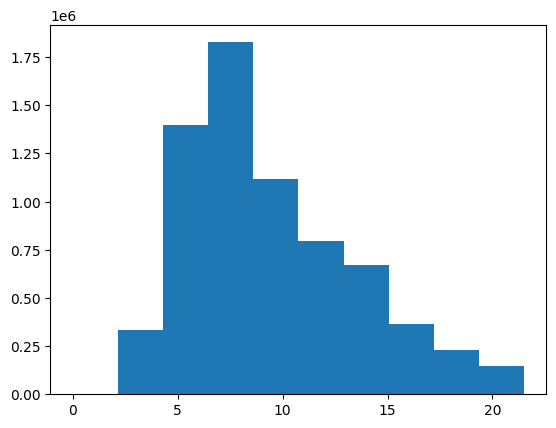

In [62]:
plt.hist(df1['fare_amount'])

{'whiskers': [<matplotlib.lines.Line2D at 0x271c8a3fc50>,
 'caps': [<matplotlib.lines.Line2D at 0x271c8a3fed0>,
 'boxes': [<matplotlib.lines.Line2D at 0x271c8a3fb10>],
 'medians': [<matplotlib.lines.Line2D at 0x271c8a74190>],
 'fliers': [<matplotlib.lines.Line2D at 0x271c8a742d0>],
 'means': []}

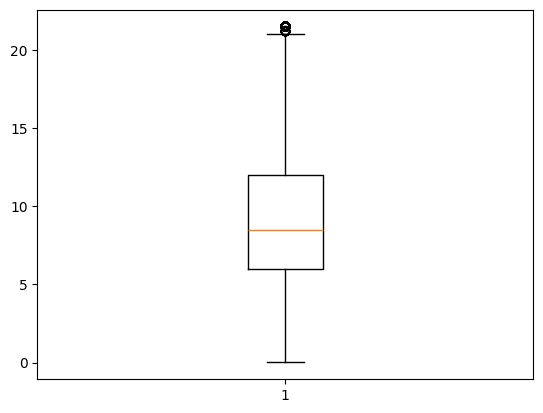

In [61]:
# Checking the outliers using boxblot
plt.boxplot(df1['fare_amount'])

## Outlier Removal Using IQR Method

In [60]:
for col in ['trip_distance','fare_amount','duration']:
    q1=df1[col].quantile(.25)
    q3=df1[col].quantile(.75)
    IQR=q3-q1

    lower_bound=q1-1.5*IQR
    upper_bound=q3+1.5*IQR

    df1=df1[(df1[col]>=lower_bound)&(df1[col]<=upper_bound)]

df1



,passenger_count,trip_distance,fare_amount,total_amount,pickup_datetime,dropoff_datetime,payment_type,duration
0,1,2.40,10.5,12.80,2015-04-11 00:47:57,2015-04-11 00:58:14,Card,10.283333
2,1,2.40,13.0,17.25,2015-06-16 10:25:46,2015-06-16 10:43:38,Card,17.866667
3,1,2.10,9.5,12.30,2015-02-09 19:04:37,2015-02-09 19:14:23,Card,9.766667
4,1,0.91,5.0,7.56,2015-03-13 21:24:17,2015-03-13 21:27:19,Card,3.033333
5,1,1.10,7.0,8.80,2015-05-01 16:48:21,2015-05-01 16:55:57,Cash,7.600000
...,...,...,...,...,...,...,...,...
8359225,2,1.57,8.0,9.30,2015-01-11 01:01:54,2015-01-11 01:09:56,Cash,8.033333
8359226,1,2.20,11.5,15.35,2015-06-11 20:06:32,2015-06-11 20:22:24,Card,15.866667
8359227,1,2.19,9.5,13.00,2015-04-03 18:58:06,2015-04-03 19:08:04,Card,9.966667
8359228,3,1.08,6.0,8.58,2015-02-19 19:27:35,2015-02-19 19:33:32,Card,5.950000


## Exploratory Analysis of Payment Methods

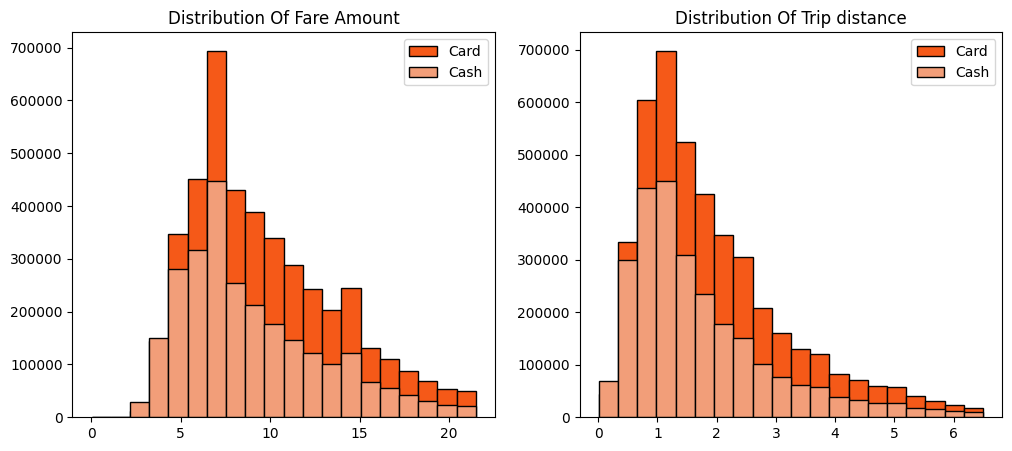

In [79]:
# Showing the histogram plot for the preferance of payment method 
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Distribution Of Fare Amount')
plt.hist(df1[df1['payment_type']=='Card']['fare_amount'], histtype='barstacked',bins=20,edgecolor='k',color='#F55918',label='Card')
plt.hist(df1[df1['payment_type']=='Cash']['fare_amount'], histtype='barstacked',bins=20,edgecolor='k',color='#F29E79',label='Cash')
plt.legend()

plt.subplot(1,2,2)
plt.title('Distribution Of Trip distance')
plt.hist(df1[df1['payment_type']=='Card']['trip_distance'], histtype='barstacked',bins=20,edgecolor='k',color='#F55918',label='Card')
plt.hist(df1[df1['payment_type']=='Cash']['trip_distance'], histtype='barstacked',bins=20,edgecolor='k',color='#F29E79',label='Cash')
plt.legend()
plt.show()

In [81]:
# Compare fare amount and trip distance by payment method 
df1.groupby('payment_type').agg({'fare_amount':['mean','median'],'trip_distance':['mean','median']})

fare_amount        trip_distance       
                    mean median          mean median
payment_type                                        
Card            9.706191    9.0      1.943910   1.60
Cash            8.955740    8.0      1.719263   1.39

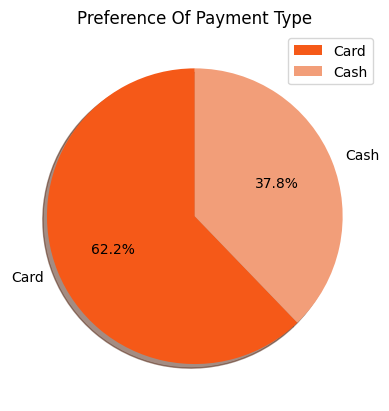

In [90]:
# Showing the preference using pie chart 
plt.title('Preference Of Payment Type')
plt.pie(df1['payment_type'].value_counts(normalize=True),labels=df1['payment_type'].value_counts().index,colors=['#F55918','#F29E79'],startangle=90,
       shadow=True,autopct='%1.1f%%')
plt.legend()
plt.show()

In [98]:
# Analyze passenger count by payment type
passenger_count=df1.groupby(['payment_type','passenger_count'])[['passenger_count']].count()
passenger_count.rename(columns={'passenger_count':'count'}, inplace=True)
passenger_count.reset_index(inplace=True)
passenger_count

,payment_type,passenger_count,count
0,Card,1,3202155
1,Card,2,595299
2,Card,3,170480
3,Card,4,74678
4,Card,5,243012
5,Cash,1,1870166
6,Cash,2,399267
7,Cash,3,122985
8,Cash,4,64566
9,Cash,5,146670


In [100]:
# Showing the total passenger count in percentage form 
passenger_count['perct']=(passenger_count['count']/passenger_count['count'].sum())*100
passenger_count

,payment_type,passenger_count,count,perct
0,Card,1,3202155,46.480270
1,Card,2,595299,8.640949
2,Card,3,170480,2.474570
3,Card,4,74678,1.083974
4,Card,5,243012,3.527394
5,Cash,1,1870166,27.146038
6,Cash,2,399267,5.795484
7,Cash,3,122985,1.785165
8,Cash,4,64566,0.937195
9,Cash,5,146670,2.128960


In [102]:
# Prepare aggregated data for visualization
df2=pd.DataFrame(columns=['payment_type',1,2,3,4,5])
df2['payment_type']=['Card','Cash']
df2.iloc[0,1:]=passenger_count.iloc[0:5,-1]
df2.iloc[1,1:]=passenger_count.iloc[5:,-1]
df2

,payment_type,1,2,3,4,5
0,Card,46.48027,8.640949,2.47457,1.083974,3.527394
1,Cash,27.146038,5.795484,1.785165,0.937195,2.12896


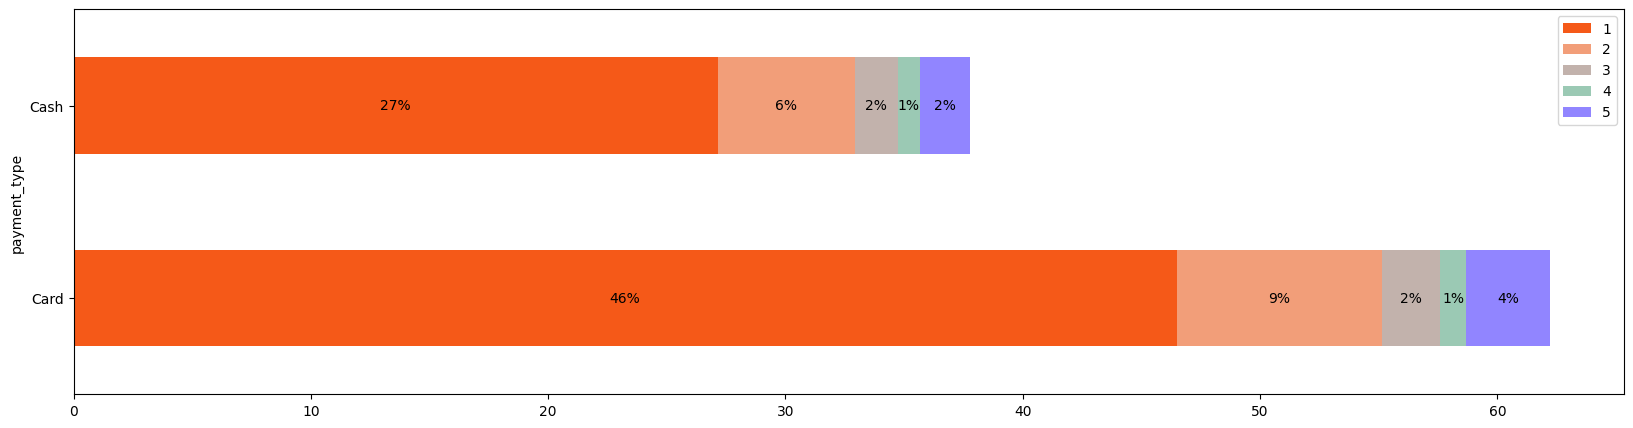

In [110]:
fig,ax=plt.subplots(figsize=(20,5))
df2.plot(x='payment_type',kind='barh',stacked=True, color=['#F55918','#F29E79','#C2B2AC','#9BC9B4','#9185FF'],ax=ax)

#adding percentage in the bar
for p in ax.patches:
    width=p.get_width()
    height=p.get_height()
    x,y=p.get_xy()
    ax.text(x+width/2,
           y+height/2,
           '{:.0f}%'.format(width),
           horizontalalignment='center',
           verticalalignment='center')
    

## Normality Assessment

Before selecting an appropriate hypothesis test, the distribution of fare amounts was examined using visual methods.

Although the dataset is sufficiently large for the Central Limit Theorem to apply, assessing normality provides additional confidence in the analytical approach.

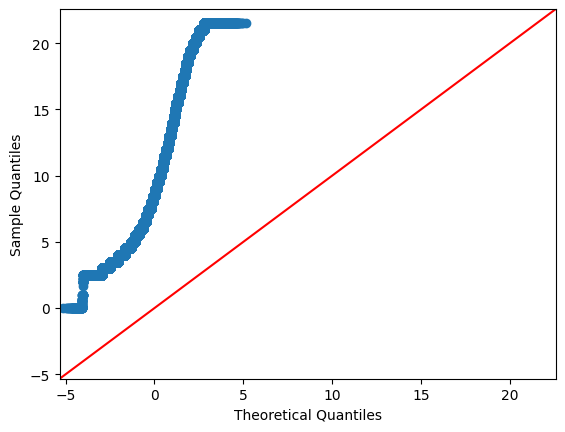

In [117]:

sm.qqplot(df1['fare_amount'],line='45')
plt.show()

# Hypothesis Formulation

## Null Hypothesis (H₀)

There is no statistically significant difference in the average fare amount between passengers who pay by credit card and those who pay by cash.

## Alternative Hypothesis (H₁)

There is a statistically significant difference in the average fare amount between passengers who pay by credit card and those who pay by cash.

In [119]:
# Draw independent samples for Welch's t-test
card_sample=df1[df1['payment_type']=='Card']['fare_amount']
cash_sample=df1[df1['payment_type']=='Cash']['fare_amount']


## Statistical Analysis

A Welch's Two-Sample t-test was performed to compare the average fare amount between the two independent payment groups.

Welch's t-test was selected because it does not assume equal variances between groups, making it a robust choice for real-world datasets.

In [121]:
# Perform Welch's two-sample t-test (unequal variances)
t_stats,p_value=st.ttest_ind(a=card_sample,b=cash_sample,equal_var=False)
print('T statistic:',t_stats, 'p_value:',p_value)

T statistic: 236.98054045571698 p_value: 0.0


## Interpretation

The statistical test produced a p-value below the significance level of 0.05.

Therefore, the null hypothesis was rejected.

The analysis indicates that payment method is associated with a statistically significant difference in average fare amount.

## Business Insight

The findings suggest that passengers paying by credit card generally generate higher fare amounts than those paying by cash.

Possible explanations include:

- Longer trip distances
- Greater customer convenience
- Higher adoption of digital payment methods
- Different customer spending behavior

These insights can support business strategies aimed at encouraging digital payment adoption.

## Future Work

This analysis can be extended by:

- Building regression models to predict fare amount
- Investigating additional explanatory variables such as trip distance and trip duration
- Performing time-series analysis to identify seasonal travel patterns
- Developing an interactive dashboard for business stakeholders
- Applying machine learning techniques for fare prediction